In [2]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

# 전역 device / dtype 설정
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
dtype  = torch.float64   # dynamics 수치 정확도를 위해 float64 사용

print(f"device : {device}")
print(f"PyTorch: {torch.__version__}")

device : cpu
PyTorch: 2.11.0+cu128


# Spacecraft + CMG Dynamics
Reference: Oghim et al., *"Deep reinforcement learning-based attitude control for spacecraft using control moment gyros"*, ASR 2025

## 1. Quaternion Utilities

In [3]:
# ── 쿼터니언 유틸리티 ──────────────────────────────────────────────────────
# 모든 함수는 배치 차원을 지원: shape (..., 4) 또는 (..., 3)

def quat_mult(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    """Hamilton product p ⊗ q.  shape: (..., 4), scalar-first [qw, qx, qy, qz]."""
    pw, px, py, pz = p[..., 0], p[..., 1], p[..., 2], p[..., 3]
    qw, qx, qy, qz = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    return torch.stack([
        pw*qw - px*qx - py*qy - pz*qz,
        pw*qx + px*qw + py*qz - pz*qy,
        pw*qy - px*qz + py*qw + pz*qx,
        pw*qz + px*qy - py*qx + pz*qw,
    ], dim=-1)

def quat_conj(q: torch.Tensor) -> torch.Tensor:
    """Conjugate [qw, -qv].  shape: (..., 4)."""
    return torch.cat([q[..., :1], -q[..., 1:]], dim=-1)

def quat_normalize(q: torch.Tensor) -> torch.Tensor:
    """단위 쿼터니언 정규화.  shape: (..., 4)."""
    return q / q.norm(dim=-1, keepdim=True).clamp(min=1e-12)

def quat_kinematics(q: torch.Tensor, omega: torch.Tensor) -> torch.Tensor:
    """q̇ = (1/2) q ⊗ Ω,  Ω = [0, ω]  (Eq. 1).
    shape: (..., 4) & (..., 3) → (..., 4)."""
    Omega = torch.cat([torch.zeros_like(omega[..., :1]), omega], dim=-1)
    return 0.5 * quat_mult(q, Omega)

def attitude_error_quat(q: torch.Tensor, q_d: torch.Tensor):
    """qe = qd* ⊗ q  (Eq. 2).  shape: (..., 4) → (qe, qve).
    qve 는 오차 쿼터니언의 벡터 파트 (..., 3)."""
    qe = quat_mult(quat_conj(q_d), q)
    return qe, qe[..., 1:]

print("Quaternion utilities defined.")

Quaternion utilities defined.


## 2. CMG Jacobian (Pyramid-type)

In [4]:
# ── 피라미드형 CMG 함수 ─────────────────────────────────────────────────────
# 모든 함수는 배치 차원을 지원: delta shape (..., 4)

def cmg_angular_momentum(delta: torch.Tensor, h: float, beta: float) -> torch.Tensor:
    """총 CMG 각운동량 벡터 Hcmg  (Eq. 9).
    delta: (..., 4) [rad] → (..., 3) [N·m·s]"""
    d1, d2, d3, d4 = delta[..., 0], delta[..., 1], delta[..., 2], delta[..., 3]
    cb, sb = math.cos(beta), math.sin(beta)
    return h * torch.stack([
        -cb*torch.sin(d1) - torch.cos(d2) + cb*torch.sin(d3) + torch.cos(d4),
         torch.cos(d1) - cb*torch.sin(d2) - torch.cos(d3) + cb*torch.sin(d4),
         sb*(torch.sin(d1) + torch.sin(d2) + torch.sin(d3) + torch.sin(d4)),
    ], dim=-1)

def cmg_jacobian(delta: torch.Tensor, h: float, beta: float) -> torch.Tensor:
    """자코비안 A(δ): Ḣcmg = A δ̇  (Eq. 11).
    delta: (..., 4) → (..., 3, 4)"""
    d1, d2, d3, d4 = delta[..., 0], delta[..., 1], delta[..., 2], delta[..., 3]
    cb, sb = math.cos(beta), math.sin(beta)
    row1 = torch.stack([-cb*torch.cos(d1),  torch.sin(d2),    cb*torch.cos(d3), -torch.sin(d4)  ], dim=-1)
    row2 = torch.stack([-torch.sin(d1),    -cb*torch.cos(d2),  torch.sin(d3),    cb*torch.cos(d4)], dim=-1)
    row3 = torch.stack([ sb*torch.cos(d1),  sb*torch.cos(d2),  sb*torch.cos(d3), sb*torch.cos(d4)], dim=-1)
    return h * torch.stack([row1, row2, row3], dim=-2)   # (..., 3, 4)

def singularity_measure(A: torch.Tensor) -> torch.Tensor:
    """특이점 지표 m = det(A Aᵀ).  A: (..., 3, 4) → (...,)"""
    return torch.linalg.det(A @ A.transpose(-2, -1))

print("CMG Jacobian functions defined.")

CMG Jacobian functions defined.


## 3. Steering Laws

In [5]:
# ── 조종 법칙 (단일 상태용; A: (3,4), tau: (3,)) ─────────────────────────

def pseudo_inverse_steering(A: torch.Tensor, tau_d: torch.Tensor) -> torch.Tensor:
    """의사역행렬 조종 법칙: δ̇ = Aᵀ(AAᵀ)⁻¹ τd  (Eq. 12)
    A: (3,4), tau_d: (3,) → (4,)"""
    return A.T @ torch.linalg.solve(A @ A.T, tau_d)


def gsri_steering(A: torch.Tensor, tau_c: torch.Tensor,
                  t: float, k_sr: float = 0.01) -> torch.Tensor:
    """GSRI 조종 법칙: δ̇ = Aᵀ(AAᵀ + λE)⁻¹ τc  (Eq. 27)
    A: (3,4), tau_c: (3,) → (4,)"""
    AAT = A @ A.T
    lam = k_sr * torch.exp(-10.0 * torch.linalg.det(AAT))
    e1 = 0.01 * math.sin(0.5 * math.pi * t)
    e2 = 0.01 * math.sin(0.5 * math.pi * t + math.pi / 2)
    e3 = 0.01 * math.sin(0.5 * math.pi * t + math.pi)
    E  = torch.tensor([[1., e3, e2], [e3, 1., e1], [e2, e1, 1.]],
                      dtype=A.dtype, device=A.device)
    return A.T @ torch.linalg.solve(AAT + lam * E, tau_c)


def momentum_recovery_steering(A: torch.Tensor, tau_c: torch.Tensor,
                                delta: torch.Tensor, delta0: torch.Tensor,
                                dt: float, eta: float = 0.1) -> torch.Tensor:
    """영공간 null-motion 각운동량 회복 조종 법칙 (Eq. 26)
    δ̇ = A⁺ τc + η(A⁺A − I₄) g,  g = (δ − δ0)/Δt
    A: (3,4), tau_c/delta/delta0: (3,)/(4,)/(4,) → (4,)"""
    A_pinv  = A.T @ torch.linalg.solve(A @ A.T, torch.eye(3, dtype=A.dtype, device=A.device))
    g       = (delta - delta0) / dt
    return A_pinv @ tau_c + eta * ((A_pinv @ A - torch.eye(4, dtype=A.dtype, device=A.device)) @ g)


print("Steering laws defined.")

Steering laws defined.


## 4. SpacecraftCMG Class (Dynamics)

In [6]:
class SpacecraftCMG:
    """피라미드형 4-CMG 위성 Dynamics — 배치 지원 (MPPI / DRL 대응)

    상태 벡터  x  = [q(4), ω(3), δ(4)]  →  shape (B, 11)
    행동 벡터  u  = δ̇                   →  shape (B, 4)

    운동방정식 (Eq. 6, 8):
        Jω̇ = τ − ω × Jω
        τ  = −A(δ)δ̇ − ω × Hcmg   (Eq. 7)

    기본 파라미터 (Table 2, Oghim et al. 2025):
        J    = diag(21400, 20100, 5500)  [kg·m²]
        h    = 1000  [N·m·s]
        β    = 53.13°
        δ₀   = [45, −45, 45, −45]°
        δ̇max = 1.0  [rad/s]
    """

    def __init__(
        self,
        B:             int   = 1,
        J:             torch.Tensor = None,
        h:             float = 1000.0,
        beta_deg:      float = 53.13,
        delta0_deg:    list  = None,
        delta_dot_max: float = 1.0,
        device:        torch.device = device,
        dtype:         torch.dtype  = dtype,
    ):
        self.B      = B
        self.device = device
        self.dtype  = dtype
        self.h      = h
        self.beta   = math.radians(beta_deg)
        self.delta_dot_max = delta_dot_max

        if J is None:
            J = torch.diag(torch.tensor([21400., 20100., 5500.], dtype=dtype, device=device))
        self.J     = J                           # (3, 3)
        self.J_inv = torch.linalg.inv(J)         # (3, 3)

        d0 = delta0_deg if delta0_deg is not None else [45., -45., 45., -45.]
        self.delta0 = torch.tensor(
            [math.radians(d) for d in d0], dtype=dtype, device=device)  # (4,)

        self.state = self._make_state()          # (B, 11)

    # ── 상태 슬라이스 프로퍼티 ────────────────────────────────────────────
    @property
    def q(self)     -> torch.Tensor: return self.state[:, :4]    # (B, 4)
    @property
    def omega(self) -> torch.Tensor: return self.state[:, 4:7]   # (B, 3)
    @property
    def delta(self) -> torch.Tensor: return self.state[:, 7:]    # (B, 4)

    # ── 초기화 ───────────────────────────────────────────────────────────
    def _make_state(self) -> torch.Tensor:
        s = torch.zeros(self.B, 11, dtype=self.dtype, device=self.device)
        s[:, 0]  = 1.0          # qw = 1
        s[:, 7:] = self.delta0  # 짐벌 초기각도
        return s

    def reset(self, state: torch.Tensor = None) -> torch.Tensor:
        """state 가 None 이면 기본값으로 초기화. shape: (B, 11) 또는 (11,)"""
        if state is None:
            self.state = self._make_state()
        else:
            s = state.to(device=self.device, dtype=self.dtype)
            self.state = s.unsqueeze(0) if s.dim() == 1 else s
        return self.state

    # ── 편의 프로퍼티 ────────────────────────────────────────────────────
    @property
    def A(self)    -> torch.Tensor: return cmg_jacobian(self.delta, self.h, self.beta)       # (B,3,4)
    @property
    def H_cmg(self)-> torch.Tensor: return cmg_angular_momentum(self.delta, self.h, self.beta) # (B,3)
    @property
    def sm(self)   -> torch.Tensor: return singularity_measure(self.A)                        # (B,)

    # ── 상태 미분 (배치) ─────────────────────────────────────────────────
    def _dynamics(self, state: torch.Tensor, delta_dot: torch.Tensor,
                  tau_ext: torch.Tensor = None) -> torch.Tensor:
        """
        state:     (B, 11)
        delta_dot: (B, 4)   [rad/s]  — 이미 클리핑된 값
        tau_ext:   (B, 3)   [N·m]    (선택)
        반환:      (B, 11)  상태 미분
        """
        q     = state[:, :4]   # (B, 4)
        omega = state[:, 4:7]  # (B, 3)
        delta = state[:, 7:]   # (B, 4)

        A = cmg_jacobian(delta, self.h, self.beta)             # (B, 3, 4)
        H = cmg_angular_momentum(delta, self.h, self.beta)     # (B, 3)

        # τ = −Ḣcmg − ω × Hcmg  (Eq. 7)
        H_dot = (A @ delta_dot.unsqueeze(-1)).squeeze(-1)      # (B, 3)
        tau   = -H_dot - torch.linalg.cross(omega, H, dim=-1)
        if tau_ext is not None:
            tau = tau + tau_ext

        # q̇  (Eq. 1)
        q_dot = quat_kinematics(q, omega)                      # (B, 4)

        # ω̇ = J⁻¹(τ − ω × Jω)  (Eq. 8)
        Jw       = (self.J @ omega.unsqueeze(-1)).squeeze(-1)  # (B, 3)
        omega_dot = (self.J_inv @ (tau - torch.linalg.cross(omega, Jw, dim=-1)
                                   ).unsqueeze(-1)).squeeze(-1) # (B, 3)

        return torch.cat([q_dot, omega_dot, delta_dot], dim=-1)  # (B, 11)

    # ── RK4 한 스텝 ──────────────────────────────────────────────────────
    def step(self, delta_dot_cmd: torch.Tensor, dt: float,
             tau_ext: torch.Tensor = None) -> torch.Tensor:
        """
        delta_dot_cmd: (B, 4) 또는 (4,)  [rad/s]
        반환: 새 state (B, 11)
        """
        u = delta_dot_cmd
        if u.dim() == 1:
            u = u.unsqueeze(0).expand(self.B, -1)
        u = u.clamp(-self.delta_dot_max, self.delta_dot_max)

        f  = lambda s: self._dynamics(s, u, tau_ext)
        s0 = self.state
        k1 = f(s0)
        k2 = f(s0 + 0.5*dt*k1)
        k3 = f(s0 + 0.5*dt*k2)
        k4 = f(s0 +     dt*k3)

        s_new = s0 + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
        s_new[:, :4] = quat_normalize(s_new[:, :4])   # 쿼터니언 정규화
        self.state = s_new
        return self.state

    # ── 자세 오차 ────────────────────────────────────────────────────────
    def attitude_error(self, q_d: torch.Tensor):
        """q_d: (4,) 또는 (B, 4) → (qe, qve) 각각 (B,4), (B,3)"""
        if q_d.dim() == 1:
            q_d = q_d.unsqueeze(0).expand(self.B, -1)
        return attitude_error_quat(self.q, q_d)


print("SpacecraftCMG class defined.")

SpacecraftCMG class defined.


## 5. 기존 컨트롤러 (Phase 2, Eq. 25)

In [7]:
def conventional_controller(qe: torch.Tensor, omega: torch.Tensor,
                             J: torch.Tensor,
                             omega_n: float = 3.0,
                             zeta:    float = 0.9,
                             T:       float = 10.0,
                             torque_limit: float = 3000.0,
                             omega_max_deg: float = 30.0) -> torch.Tensor:
    """쿼터니언 오차 피드백 제어 (Eq. 25).  배치 지원.
    qe: (B,4), omega: (B,3) → tau_c: (B,3)

    τc = −J_diag { 2k sat_{Li}(qve) + c ω }
    Li = (c/2k) * min(√(4k|qve,i|), ωmax)
    """
    qve = qe[:, 1:]   # (B, 3)
    k   = omega_n**2 + 2*zeta*omega_n / T
    c   = 2*zeta*omega_n + 1.0 / T
    omega_max = math.radians(omega_max_deg)

    Li      = (c / (2*k)) * torch.minimum(
                  (4*k * qve.abs()).sqrt(),
                  torch.full_like(qve, omega_max))              # (B, 3)
    sat_qve = torch.where(qve >  Li,  Li,
              torch.where(qve < -Li, -Li, qve))                 # (B, 3)

    J_diag = torch.diag(J)                                      # (3,)
    tau_c  = -J_diag * (2*k * sat_qve + c * omega)             # (B, 3)
    return tau_c.clamp(-torque_limit, torque_limit)


print("Conventional controller defined.")

Conventional controller defined.


## 6. 시뮬레이션 — Yaw 70° 단축 기동 (논문 Fig. 5–8 재현)

In [ ]:
# ── 시뮬레이션 파라미터 ────────────────────────────────────────────────────
dt    = 0.1
T_max = 30.0
steps = int(T_max / dt)
time  = torch.arange(steps, dtype=dtype) * dt

bq = 0.04   # Phase 1 → 2 전환 임계값

# 목표 자세: Yaw 70° (z축 회전)
angle = math.radians(30.0)
q_d = torch.tensor([math.cos(angle/2), 0., 0., math.sin(angle/2)],
                   dtype=dtype, device=device)

# ── 위성 객체 생성 (B=1) ──────────────────────────────────────────────────
sc = SpacecraftCMG(B=1, device=device, dtype=dtype)
sc.reset()

# ── 로그 (CPU tensor) ─────────────────────────────────────────────────────
log_qe    = torch.zeros(steps, 4,  dtype=dtype)
log_omega = torch.zeros(steps, 3,  dtype=dtype)
log_ddot  = torch.zeros(steps, 4,  dtype=dtype)
log_sm    = torch.zeros(steps,     dtype=dtype)
log_phase = torch.zeros(steps,     dtype=torch.int32)

# ── 시뮬레이션 루프 ────────────────────────────────────────────────────────
with torch.no_grad():
    for i in range(steps):
        t = time[i].item()

        qe, qve = sc.attitude_error(q_d)          # (1,4), (1,3)
        tau_d   = conventional_controller(qe, sc.omega, sc.J)   # (1,3)

        # 조종 법칙은 단일 상태용 → squeeze
        A_s     = sc.A.squeeze(0)                  # (3,4)
        tau_s   = tau_d.squeeze(0)                 # (3,)
        delta_s = sc.delta.squeeze(0)              # (4,)

        if qve.norm().item() > bq:                 # Phase 1: GSRI
            ddot = gsri_steering(A_s, tau_s, t)    # (4,)
            log_phase[i] = 1
        else:                                      # Phase 2: 각운동량 회복
            ddot = momentum_recovery_steering(A_s, tau_s, delta_s, sc.delta0, dt)
            log_phase[i] = 2

        sc.step(ddot, dt)                          # (B=1, 4) or (4,) 모두 OK

        log_qe[i]    = qe.squeeze(0).cpu()
        log_omega[i] = torch.rad2deg(sc.omega.squeeze(0)).cpu()
        log_ddot[i]  = ddot.cpu()
        log_sm[i]    = sc.sm.cpu()

switch_idx = (log_phase == 2).nonzero(as_tuple=True)[0]
switch_t   = time[switch_idx[0]].item() if len(switch_idx) else T_max
print(f"Phase 전환 시각  : {switch_t:.1f} s")
print(f"최종 자세 오차 |qve|: {log_qe[-1, 1:].norm().item():.6f}")

Phase 전환 시각  : 9.5 s
최종 자세 오차 |qve|: 0.364160


C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 53244 (\N{HANGUL SYLLABLE KWEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_37364\2909638449.py:30: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) 

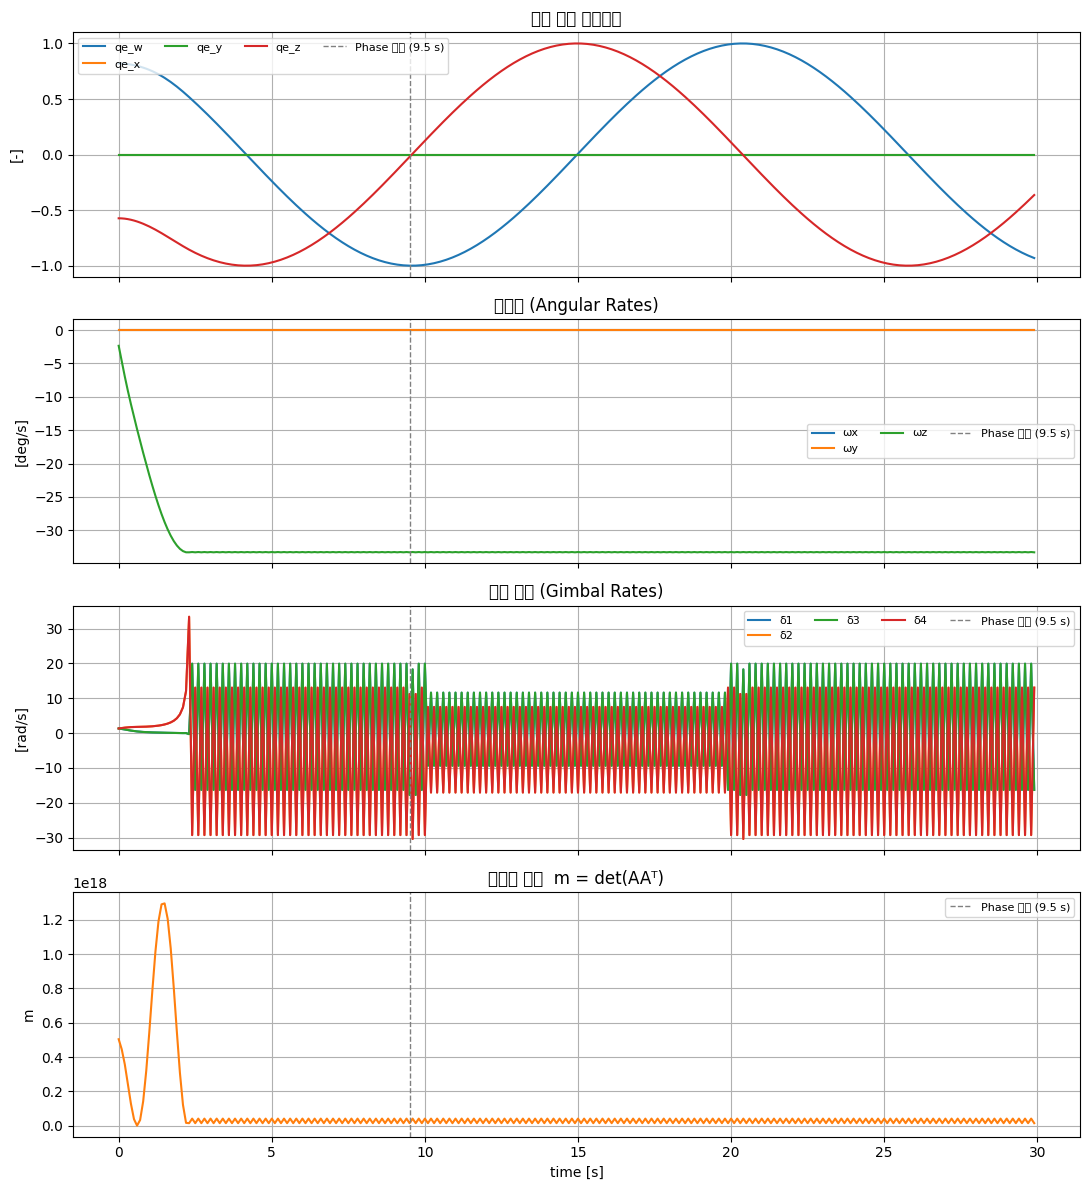

In [9]:
t_np = time.numpy()
vline_kw = dict(color="gray", linestyle="--", linewidth=1.0, label=f"Phase 전환 ({switch_t:.1f} s)")

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

axes[0].set_title("자세 오차 쿼터니언")
for j, lbl in enumerate(["qe_w", "qe_x", "qe_y", "qe_z"]):
    axes[0].plot(t_np, log_qe[:, j].numpy(), label=lbl)
axes[0].axvline(switch_t, **vline_kw)
axes[0].legend(ncol=4, fontsize=8); axes[0].set_ylabel("[-]"); axes[0].grid(True)

axes[1].set_title("각속도 (Angular Rates)")
for j, lbl in enumerate(["ωx", "ωy", "ωz"]):
    axes[1].plot(t_np, log_omega[:, j].numpy(), label=lbl)
axes[1].axvline(switch_t, **vline_kw)
axes[1].legend(ncol=3, fontsize=8); axes[1].set_ylabel("[deg/s]"); axes[1].grid(True)

axes[2].set_title("짐벌 속도 (Gimbal Rates)")
for j in range(4):
    axes[2].plot(t_np, log_ddot[:, j].numpy(), label=f"δ̇{j+1}")
axes[2].axvline(switch_t, **vline_kw)
axes[2].legend(ncol=4, fontsize=8); axes[2].set_ylabel("[rad/s]"); axes[2].grid(True)

axes[3].set_title("특이점 지표  m = det(AAᵀ)")
axes[3].plot(t_np, log_sm.numpy(), color="tab:orange")
axes[3].axvline(switch_t, **vline_kw)
axes[3].set_ylabel("m"); axes[3].set_xlabel("time [s]"); axes[3].grid(True)
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()